In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv("population_growth.csv", skiprows=4)
df = df.drop(columns=['1960', 'Indicator Code', 'Unnamed: 68'])
df.head(3)

,Country Name,Country Code,Indicator Name,1961,1962,1963,1964,1965,1966,1967,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,Population growth (annual %),1.187344,1.326227,1.203664,1.076602,0.986114,0.862399,0.503043,...,1.065512,1.023701,0.757968,0.007358,0.158976,0.270505,-0.565684,-0.820211,-0.362774,0.045652
1,Africa Eastern and Southern,AFE,Population growth (annual %),2.662249,2.723434,2.751208,2.808573,2.849732,2.850186,2.885662,...,2.740997,2.733524,2.675920,2.677279,2.771987,2.759057,2.736283,2.684849,2.626659,2.552859
2,Afghanistan,AFG,Population growth (annual %),1.962239,2.044523,2.105208,2.161195,2.233709,2.269651,2.306668,...,3.632519,3.119959,2.535720,2.808337,2.910810,2.984389,3.153609,2.356098,1.435704,2.135594


In [4]:
df_new = pd.read_csv("population_death.csv", skiprows=4)
df_new = df_new.drop(columns=['2023', 'Indicator Code', 'Unnamed: 68'])
df_new.head(3)

,Country Name,Country Code,Indicator Name,1960,1961,1962,1963,1964,1965,1966,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Aruba,ABW,"Death rate, crude (per 1,000 people)",6.594000,6.456000,6.394000,6.275000,6.250000,6.216000,6.047000,...,7.403000,7.729000,7.968000,8.336000,8.414000,8.597000,8.778000,9.690000,11.235000,11.084000
1,Africa Eastern and Southern,AFE,"Death rate, crude (per 1,000 people)",20.909191,20.671204,20.381392,20.244874,19.792984,19.784305,20.036369,...,8.778715,8.479028,8.243002,7.977151,7.776931,7.593153,7.441198,7.629831,8.049246,7.857561
2,Afghanistan,AFG,"Death rate, crude (per 1,000 people)",31.921000,31.349000,30.845000,30.359000,29.867000,29.389000,28.872000,...,7.478000,7.395000,7.331000,7.077000,7.027000,6.981000,6.791000,7.113000,7.344000,6.906000


In [6]:
df_new1 = pd.read_csv("population_total.csv", skiprows=4)
df_new1 = df_new1.drop(columns=['Indicator Code'])
df_new1.head(3)

,Country Name,Country Code,Indicator Name,1960,1961,1962,1963,1964,1965,1966,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,"Population, total",54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,58694.0,...,106807.0,107906.0,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0
1,Africa Eastern and Southern,AFE,"Population, total",130072080.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,153281203.0,...,590968990.0,607123269.0,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0
2,Afghanistan,AFG,"Population, total",9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,10266395.0,...,32792523.0,33831764.0,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0


In [89]:
df_new_birth = pd.read_csv("population_birth.csv", skiprows=4)
df_new_birth = df_new_birth.drop(columns=['Indicator Code', 'Unnamed: 68', '2023'])
df_new_birth.head(3)

,Country Name,Country Code,Indicator Name,1960,1961,1962,1963,1964,1965,1966,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Aruba,ABW,"Birth rate, crude (per 1,000 people)",33.883000,32.831000,31.649000,30.416000,29.14700,27.889000,26.663000,...,13.316000,13.533000,12.428000,12.300000,11.530000,9.8810,9.138000,8.102000,7.193000,7.178000
1,Africa Eastern and Southern,AFE,"Birth rate, crude (per 1,000 people)",47.437825,47.527899,47.593643,47.631188,47.63984,47.661907,47.692905,...,36.453947,36.034648,35.620577,35.198243,34.903496,34.6192,34.344956,33.915113,33.539503,33.128841
2,Afghanistan,AFG,"Birth rate, crude (per 1,000 people)",50.340000,50.443000,50.570000,50.703000,50.83100,50.872000,50.986000,...,39.601000,39.105000,38.803000,37.936000,37.342000,36.9270,36.466000,36.051000,35.842000,35.143000


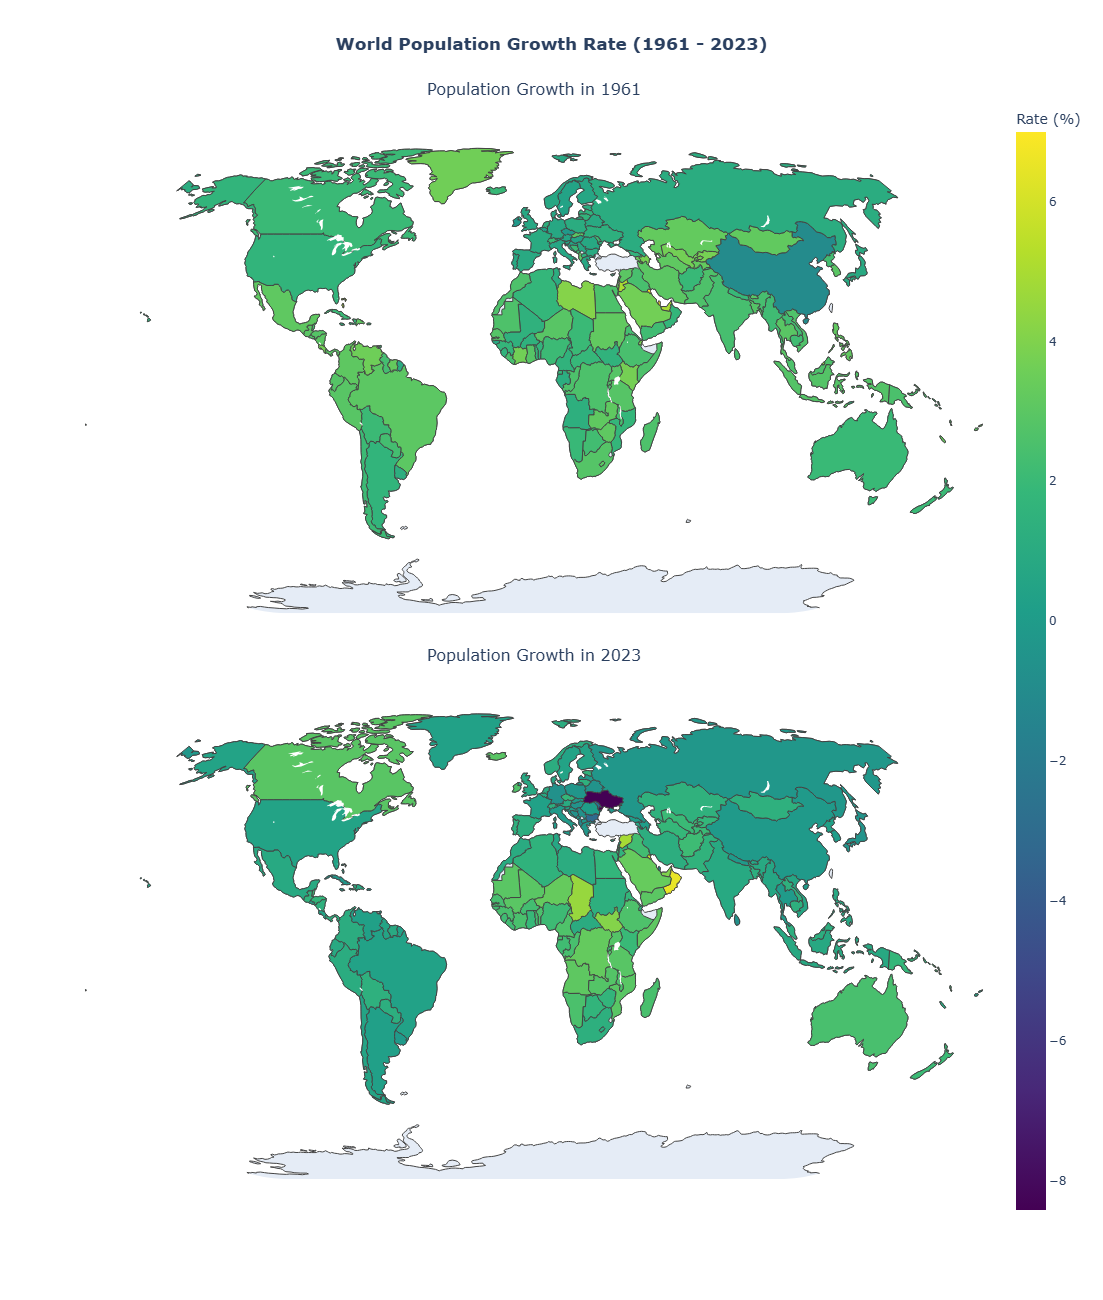

In [91]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

year_1 = "1961"
year_2 = "2023"
# Prepare data
df_1 = df[["Country Name", year_1]].copy()
df_1.columns = ["Country", "Population Growth (%)"]
df_1 = df_1.dropna()
df_2 = df[["Country Name", year_2]].copy()
df_2.columns = ["Country", "Population Growth (%)"]
df_2 = df_2.dropna()
# Create vertically stacked
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=(f"Population Growth in {year_1}", f"Population Growth in {year_2}"),
    specs=[[{"type": "choropleth"}], [{"type": "choropleth"}]],
    vertical_spacing=0.01
)
zmin = min(df_1["Population Growth (%)"].min(), df_2["Population Growth (%)"].min())
zmax = 7
# plot map
fig.add_trace(
    go.Choropleth(
        locations=df_1["Country"],
        locationmode="country names",
        z=df_1["Population Growth (%)"],
        colorscale="Viridis",
        zmin=zmin,
        zmax=zmax,
        colorbar_title="Rate (%)",
        showscale=True
    ),
    row=1, col=1
)
# plot map
fig.add_trace(
    go.Choropleth(
        locations=df_2["Country"],
        locationmode="country names",
        z=df_2["Population Growth (%)"],
        colorscale="Viridis",
        zmin=zmin,
        zmax=zmax,
        showscale=False
    ),
    row=2, col=1
)
fig.update_layout(
    title_text="<b>World Population Growth Rate (1961 - 2023)</b>",
    title_x=0.5,
    height=1300,
    width=1100,
    geo=dict(showframe=False, showcoastlines=True, projection_type="natural earth"),
    geo2=dict(showframe=False, showcoastlines=True, projection_type="natural earth")
)
fig.show()

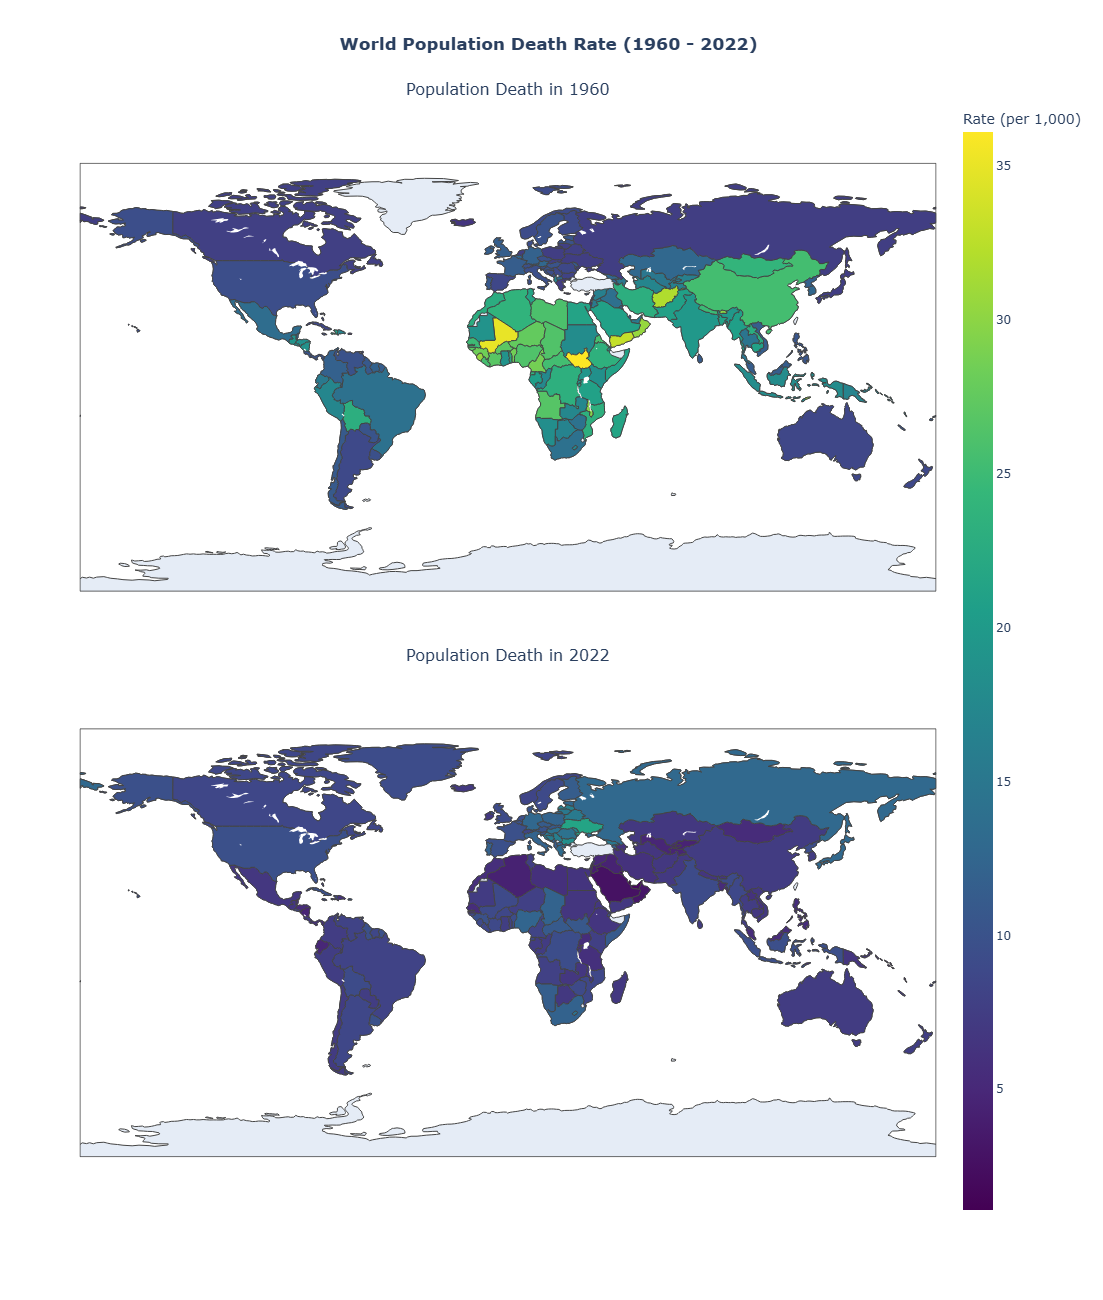

In [93]:
year_3 = "1960"
year_4 = "2022"
# Prepare data
df_3 = df_new[["Country Name", year_3]].copy()
df_3.columns = ["Country", "Population Death (%)"]
df_3 = df_3.dropna()
df_4 = df_new[["Country Name", year_4]].copy()
df_4.columns = ["Country", "Population Death (%)"]
df_4 = df_4.dropna()

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=(f"Population Death in {year_3}", f"Population Death in {year_4}"),
    specs=[[{"type": "choropleth"}], [{"type": "choropleth"}]],
    vertical_spacing=0.01
)
zmin = min(df_3["Population Death (%)"].min(), df_4["Population Death (%)"].min())
zmax = max(df_3["Population Death (%)"].max(), df_4["Population Death (%)"].max())

# plot map
fig.add_trace(
    go.Choropleth(
        locations=df_3["Country"],
        locationmode="country names",
        z=df_3["Population Death (%)"],
        colorscale="Viridis",
        zmin=zmin,
        zmax=zmax,
        colorbar_title="Rate (per 1,000)",
        showscale=True
    ),
    row=1, col=1
)
# plot map
fig.add_trace(
    go.Choropleth(
        locations=df_4["Country"],
        locationmode="country names",
        z=df_4["Population Death (%)"],
        colorscale="Viridis",
        zmin=zmin,
        zmax=zmax,
        showscale=False
    ),
    row=2, col=1
)
fig.update_layout(
    title_text="<b>World Population Death Rate (1960 - 2022) </b>",
    title_x=0.5,
    height=1300,
    width=1100,
    geo3=dict(showframe=False, showcoastlines=True, projection_type="natural earth"),
    geo4=dict(showframe=False, showcoastlines=True, projection_type="natural earth")
)
fig.show()

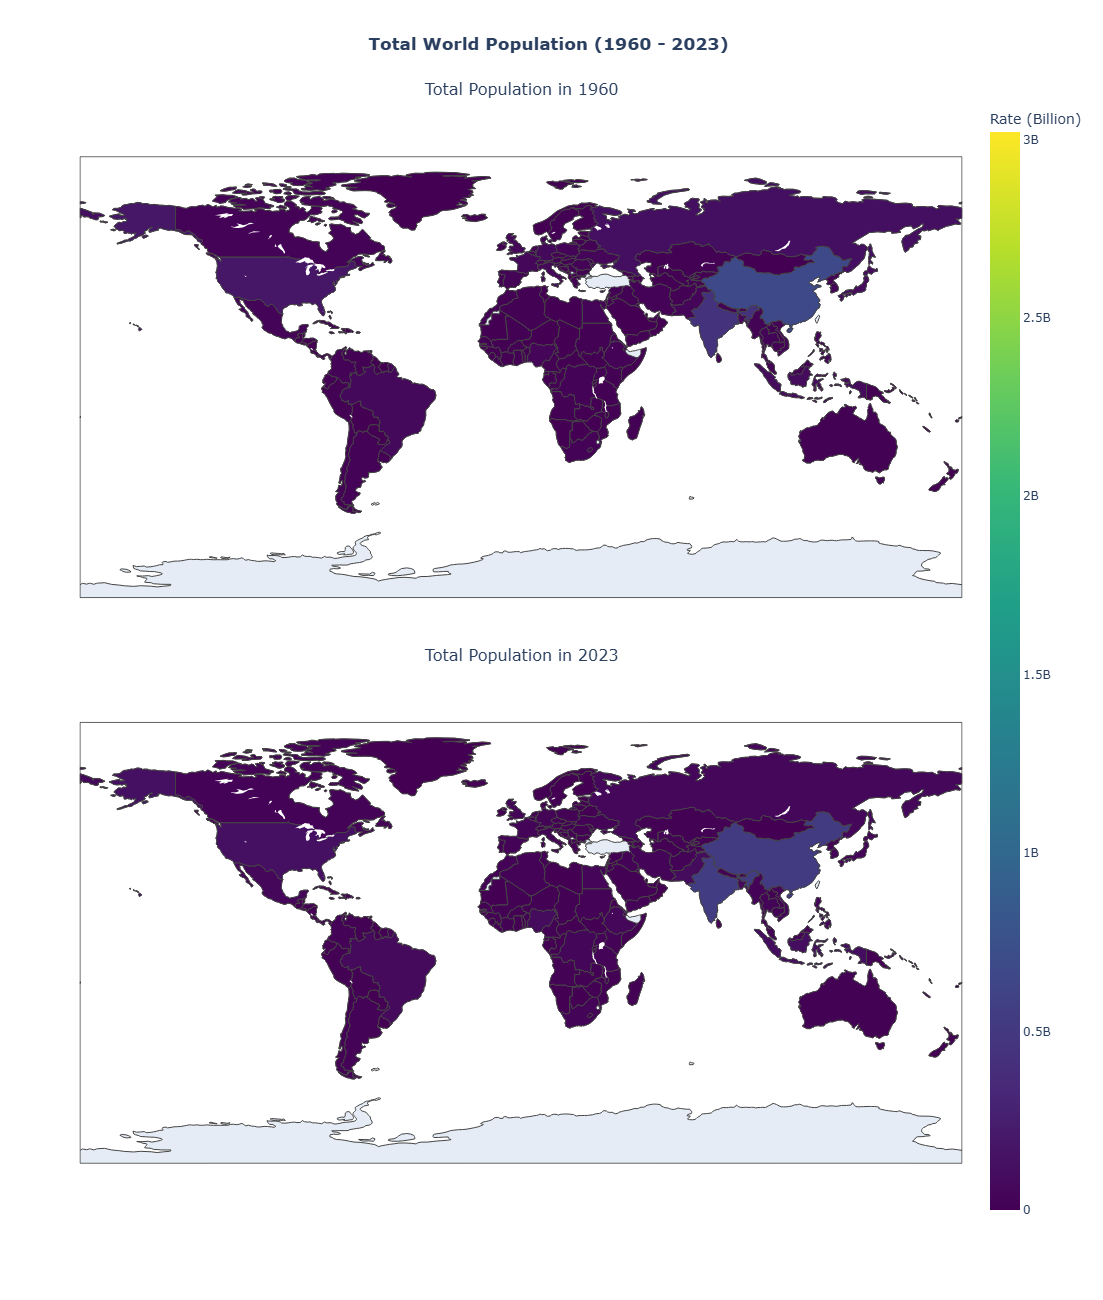

In [95]:
year_5 = "1960"
year_6 = "2023"

# Prepare data
df_5 = df_new1[["Country Name", year_5]].copy()
df_5.columns = ["Country", "Total Population"]
df_5 = df_5.dropna()
df_6 = df_new1[["Country Name", year_6]].copy()
df_6.columns = ["Country", "Total Population"]
df_6 = df_6.dropna()

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=(f"Total Population in {year_5}", f"Total Population in {year_6}"),
    specs=[[{"type": "choropleth"}], [{"type": "choropleth"}]],
    vertical_spacing=0.01
)
# Shared color scale
zmin = min(df_5["Total Population"].min(), df_6["Total Population"].min())
zmax = 3

# plot map
fig.add_trace(
    go.Choropleth(
        locations=df_5["Country"],
        locationmode="country names",
        z=df_5["Total Population"],
        colorscale="Viridis",
        zmin=zmin,
        zmax=zmax,
        colorbar_title="Rate (Billion)",
        showscale=True
    ),
    row=1, col=1
)
# plot map
fig.add_trace(
    go.Choropleth(
        locations=df_6["Country"],
        locationmode="country names",
        z=df_6["Total Population"],
        colorscale="Viridis",
        zmin=zmin,
        zmax=zmax,
        showscale=False
    ),
    row=2, col=1
)
fig.update_layout(
    title_text="<b>Total World Population (1960 - 2023) </b>",
    title_x=0.5,
    height=1300,
    width=1100,
    geo5=dict(showframe=False, showcoastlines=True, projection_type="natural earth"),
    geo6=dict(showframe=False, showcoastlines=True, projection_type="natural earth")
)
fig.show()

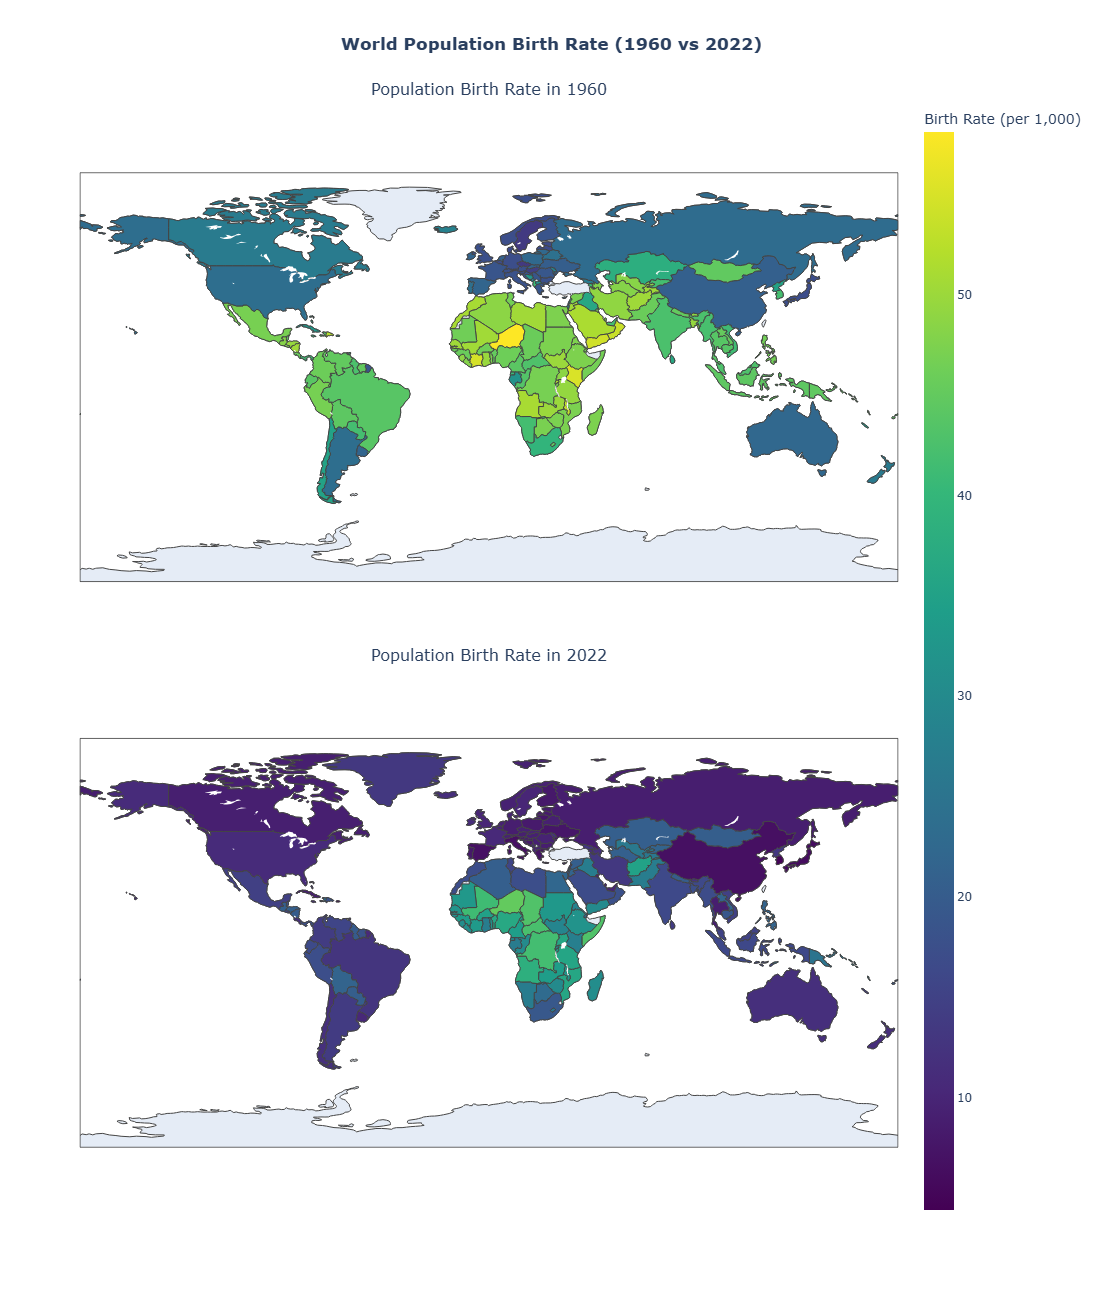

In [97]:
year_7 = "1960"
year_8 = "2022"

# Prepare dat
df_7 = df_new_birth[["Country Name", year_7]].copy()
df_7.columns = ["Country", "Population Birth Rate"]
df_7 = df_7.dropna()
df_8 = df_new_birth[["Country Name", year_8]].copy()
df_8.columns = ["Country", "Population Birth Rate"]
df_8 = df_8.dropna()
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=(f"Population Birth Rate in {year_7}", f"Population Birth Rate in {year_8}"),
    specs=[[{"type": "choropleth"}], [{"type": "choropleth"}]],
    vertical_spacing=0.01
)
# Shared color scale
zmin = min(df_7["Population Birth Rate"].min(), df_8["Population Birth Rate"].min())
zmax = max(df_7["Population Birth Rate"].max(), df_8["Population Birth Rate"].max())
# Plot for 1960
fig.add_trace(
    go.Choropleth(
        locations=df_7["Country"],
        locationmode="country names",
        z=df_7["Population Birth Rate"],
        colorscale="Viridis",
        zmin=zmin,
        zmax=zmax,
        colorbar_title="Birth Rate (per 1,000)",
        showscale=True
    ),
    row=1, col=1
)
# Plot for 2022
fig.add_trace(
    go.Choropleth(
        locations=df_8["Country"],
        locationmode="country names",
        z=df_8["Population Birth Rate"],
        colorscale="Viridis",
        zmin=zmin,
        zmax=zmax,
        showscale=False
    ),
    row=2, col=1
)
fig.update_layout(
    title_text="<b>World Population Birth Rate (1960 vs 2022)</b>",
    title_x=0.5,
    height=1300,
    width=1100,
    geo7=dict(showframe=False, showcoastlines=True, projection_type="natural earth"),
    geo8=dict(showframe=False, showcoastlines=True, projection_type="natural earth")
)
fig.show()


In [99]:
df1 = pd.read_csv("Region.csv")
df1 = df1.drop(columns=['Unnamed: 5'])
df1.head(3)

,Country Code,Region,IncomeGroup,SpecialNotes,TableName
0,ABW,Latin America & Caribbean,High income,NaN,Aruba
1,AFE,NaN,NaN,"26 countries, stretching from the Red Sea in t...",Africa Eastern and Southern
2,AFG,South Asia,Low income,The reporting period for national accounts dat...,Afghanistan


In [101]:
df2 = df.merge(df1[['Country Code', 'Region', 'IncomeGroup']], on='Country Code', how='inner')
cols = ['Country Name', 'Country Code', 'Region', 'IncomeGroup'] + [col for col in df2.columns if col not in ['Country Name', 'Country Code', 'Region', 'IncomeGroup']]
df2 = df2[cols]
df2.head(3)

,Country Name,Country Code,Region,IncomeGroup,Indicator Name,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,Latin America & Caribbean,High income,Population growth (annual %),1.187344,1.326227,1.203664,1.076602,0.986114,...,1.065512,1.023701,0.757968,0.007358,0.158976,0.270505,-0.565684,-0.820211,-0.362774,0.045652
1,Africa Eastern and Southern,AFE,NaN,NaN,Population growth (annual %),2.662249,2.723434,2.751208,2.808573,2.849732,...,2.740997,2.733524,2.675920,2.677279,2.771987,2.759057,2.736283,2.684849,2.626659,2.552859
2,Afghanistan,AFG,South Asia,Low income,Population growth (annual %),1.962239,2.044523,2.105208,2.161195,2.233709,...,3.632519,3.119959,2.535720,2.808337,2.910810,2.984389,3.153609,2.356098,1.435704,2.135594


                                1961      1962      1963      1964      1965  \
Region                                                                         
East Asia & Pacific         2.434776  2.664984  2.679007  3.147065  2.965752   
Europe & Central Asia       1.600985  1.620991  1.634078  1.598202  1.503330   
Latin America & Caribbean   2.427935  2.343857  2.601084  2.303626  2.348673   
Middle East & North Africa  3.621987  3.837276  3.836941  3.859449  3.790406   
North America               1.933862  1.984304  1.920100  1.869097  1.766558   
South Asia                  2.431185  2.474084  2.504317  2.521459  2.649120   
Sub-Saharan Africa          2.252864  2.340917  2.350364  2.359075  2.352999   

                                1966      1967      1968      1969      1970  \
Region                                                                         
East Asia & Pacific         2.375565  2.218635  2.124835  2.126190  2.270302   
Europe & Central Asia       1.417231  1

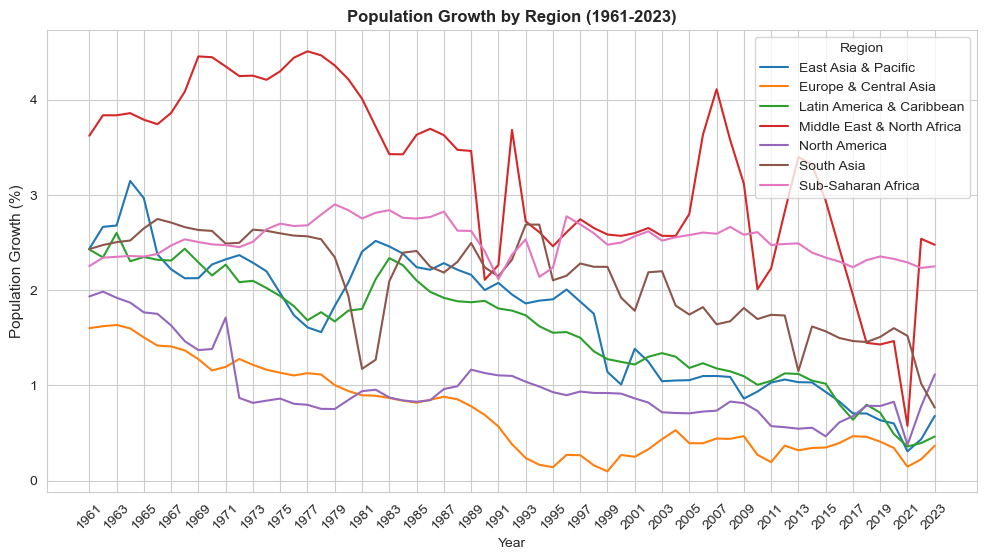

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
Evolution_by_region = df2.groupby(["Region"]).mean(numeric_only=True)
years = [str(year) for year in range(1961, 2024)]
Evolution_by_region = Evolution_by_region[years]
print (Evolution_by_region)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
for region in Evolution_by_region.index:
    plt.plot(years, Evolution_by_region.loc[region], label=region)
plt.xticks([i*2 for i in range(0,32)],fontsize=10,fontweight=550, rotation=45)
plt.xlabel("Year")
plt.ylabel("Population Growth (%)",fontsize=11)
plt.title("Population Growth by Region (1961-2023)", fontweight=600)
plt.legend(title="Region")
plt.show()

In [105]:
df_new2 = df_new1.merge(df1[['Country Code', 'Region', 'IncomeGroup']], on='Country Code', how='inner')
cols = ['Country Name', 'Country Code', 'Region', 'IncomeGroup'] + [col for col in df_new2.columns if col not in ['Country Name', 'Country Code', 'Region', 'IncomeGroup']]
df_new2 = df_new2[cols]
df_new2.head(3)

,Country Name,Country Code,Region,IncomeGroup,Indicator Name,1960,1961,1962,1963,1964,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,Latin America & Caribbean,High income,"Population, total",54922.0,55578.0,56320.0,57002.0,57619.0,...,106807.0,107906.0,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0
1,Africa Eastern and Southern,AFE,NaN,NaN,"Population, total",130072080.0,133534923.0,137171659.0,140945536.0,144904094.0,...,590968990.0,607123269.0,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0
2,Afghanistan,AFG,South Asia,Low income,"Population, total",9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,...,32792523.0,33831764.0,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0


                                    1961          1962          1963  \
Region                                                                 
East Asia & Pacific         2.793723e+07  2.831795e+07  2.900685e+07   
Europe & Central Asia       1.164741e+07  1.178176e+07  1.191706e+07   
Latin America & Caribbean   5.350889e+06  5.500911e+06  5.654754e+06   
Middle East & North Africa  5.296665e+06  5.441520e+06  5.591451e+06   
North America               6.733504e+07  6.839875e+07  6.941711e+07   
South Asia                  7.206903e+07  7.384038e+07  7.564543e+07   
Sub-Saharan Africa          4.859200e+06  4.979717e+06  5.104890e+06   

                                    1964          1965          1966  \
Region                                                                 
East Asia & Pacific         2.968675e+07  3.038431e+07  3.116637e+07   
Europe & Central Asia       1.205273e+07  1.218420e+07  1.230075e+07   
Latin America & Caribbean   5.811442e+06  5.970261e+06  6.13067

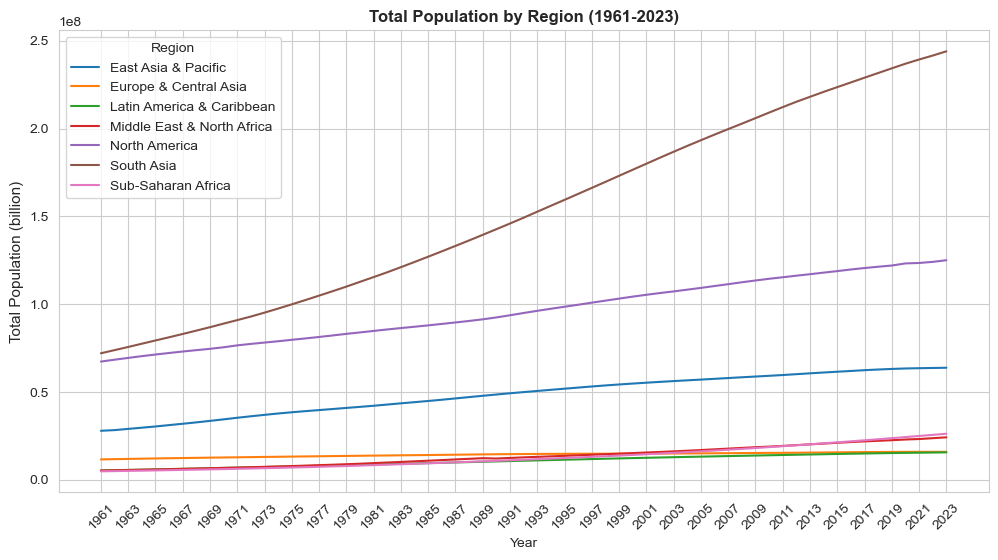

In [107]:
total_population1 = df_new2.groupby(["Region"]).mean(numeric_only=True)
years = [str(year) for year in range(1961, 2024)]
total_population1 = total_population1[years]
print (total_population1)
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
for region in total_population1.index:
    plt.plot(years, total_population1.loc[region], label=region)
plt.xticks([i*2 for i in range(0,32)],fontsize=10,fontweight=550, rotation=45)
plt.xlabel("Year")
plt.ylabel("Total Population (billion)",fontsize=11)
plt.title("Total Population by Region (1961-2023)", fontweight=600)
plt.legend(title="Region")
plt.show()

In [109]:
# The world population growth
world_population_by_year = df[df["Country Name"] == "World"].copy()
world_population_by_year = world_population_by_year.drop(columns=['Country Name', 'Country Code', 'Indicator Name'])
world_population_by_year

,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
259,1.36488,1.782818,2.1393,2.110202,2.083637,2.111772,2.063305,2.072498,2.098994,2.102087,...,1.219437,1.19067,1.169817,1.136879,1.081955,1.044595,1.019003,0.827958,0.868521,0.899808


In [111]:
#The death rate of the world
death_population_by_year = df_new[df_new["Country Name"] == "World"].copy()
death_population_by_year = death_population_by_year.drop(columns=['Country Name', 'Country Code', 'Indicator Name'])
death_population_by_year

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
259,17.22756,14.569443,13.600995,13.444486,13.51549,13.341392,12.923045,12.671411,12.428261,12.275394,...,7.667886,7.590075,7.579061,7.520356,7.502716,7.49683,7.479356,8.038485,8.73326,8.388869


In [113]:
#The birth rate of the world
birth_population_by_year = df_new_birth[df_new_birth["Country Name"] == "World"].copy()
birth_population_by_year = birth_population_by_year.drop(columns=['Country Name', 'Country Code', 'Indicator Name'])
birth_population_by_year

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
259,31.864856,31.12266,35.074813,36.251294,35.106656,34.449542,33.382034,33.102326,33.219398,32.727742,...,19.791538,19.704706,19.174727,19.23314,18.759427,18.237845,17.876763,17.285578,17.000756,16.699859


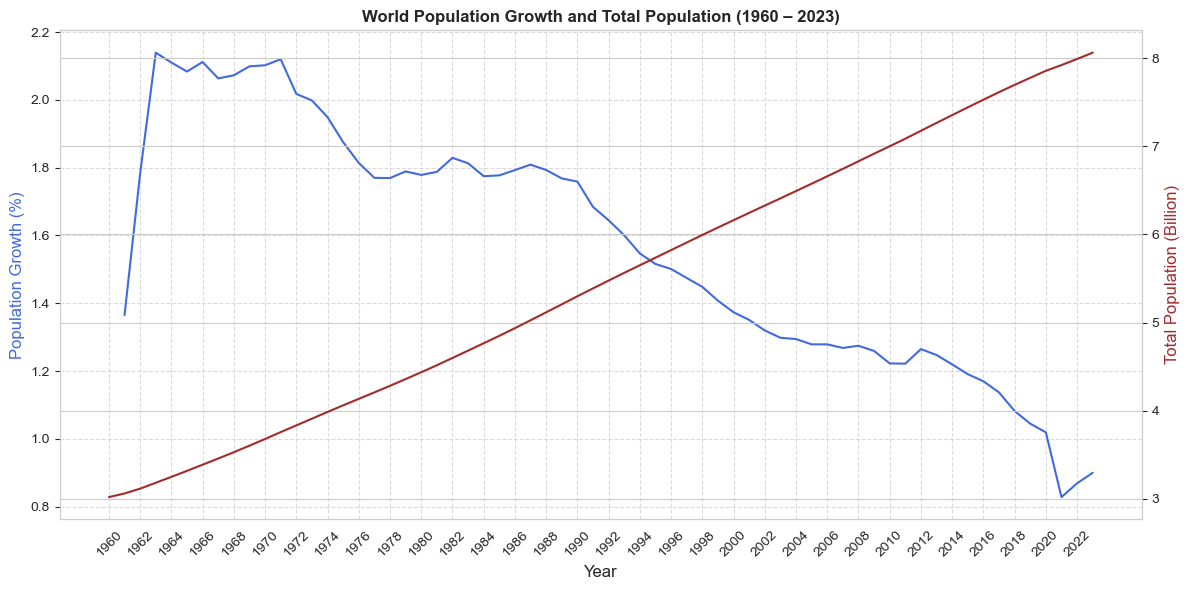

In [115]:
world_population_percentage = world_population_by_year.sum(axis=0)
world_population_percentage_df = pd.DataFrame({
    "Year": world_population_percentage.index.astype(int),
    "World Population (%)": world_population_percentage})
total_population_by_year = df_new1[df_new1["Country Name"] == "World"].copy()
years = [int(col) for col in total_population_by_year.columns if col.isdigit()]
total_population_df = pd.DataFrame({
    "Year": years,
    "Total Population": total_population_by_year.loc[:, total_population_by_year.columns.isin(map(str, years))].values.flatten()
})
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
# Left axis for Population Growth
ax1 = plt.gca()
ax1.plot(world_population_percentage_df["Year"], world_population_percentage_df["World Population (%)"],
         label="World Population Growth (%)", color="royalblue")
ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("Population Growth (%)", fontsize=12, color="royalblue")
ax1.grid(True, linestyle="--", alpha=0.7)
ax1.set_xticks(years[::2])
ax1.set_xticklabels(years[::2], rotation=45)
# Right axis for Total Population
ax2 = ax1.twinx()
ax2.plot(total_population_df["Year"], total_population_df["Total Population"] / 1e9,
         label="Total Population (Billion)", color="brown")
ax2.set_ylabel("Total Population (Billion)", fontsize=12, color="brown")
plt.title("World Population Growth and Total Population (1960 – 2023)", fontsize=12, fontweight=600)
plt.tight_layout()
plt.show()

In [117]:
df5 = df_new.merge(df1[['Country Code', 'Region', 'IncomeGroup']], on='Country Code', how='inner')
cols = ['Country Name', 'Country Code', 'Region', 'IncomeGroup'] + [col for col in df5.columns if col not in ['Country Name', 'Country Code', 'Region', 'IncomeGroup']]
df5 = df5[cols]
print(df5.head(3))

                  Country Name Country Code                     Region  \
0                        Aruba          ABW  Latin America & Caribbean   
1  Africa Eastern and Southern          AFE                        NaN   
2                  Afghanistan          AFG                 South Asia   

   IncomeGroup                        Indicator Name       1960       1961  \
0  High income  Death rate, crude (per 1,000 people)   6.594000   6.456000   
1          NaN  Death rate, crude (per 1,000 people)  20.909191  20.671204   
2   Low income  Death rate, crude (per 1,000 people)  31.921000  31.349000   

        1962       1963       1964  ...      2013      2014      2015  \
0   6.394000   6.275000   6.250000  ...  7.403000  7.729000  7.968000   
1  20.381392  20.244874  19.792984  ...  8.778715  8.479028  8.243002   
2  30.845000  30.359000  29.867000  ...  7.478000  7.395000  7.331000   

       2016      2017      2018      2019      2020       2021       2022  
0  8.336000  8.414000

                                 1960       1961       1962       1963  \
Region                                                                   
East Asia & Pacific         14.177647  13.441471  12.990412  12.673971   
Europe & Central Asia       10.830624  10.676309  10.824562  10.635537   
Latin America & Caribbean   12.476220  12.187537  11.693512  11.396366   
Middle East & North Africa  18.383750  17.792400  17.365450  16.738050   
North America                9.066667   8.500000   8.200000   8.700000   
South Asia                  23.277750  22.813500  22.347375  21.942750   
Sub-Saharan Africa          23.039638  22.700511  22.272872  22.153532   

                                 1964       1965       1966       1967  \
Region                                                                   
East Asia & Pacific         12.431382  12.100765  11.701353  11.345471   
Europe & Central Asia       10.317142  10.282697  10.144137  10.099890   
Latin America & Caribbean   10.959732

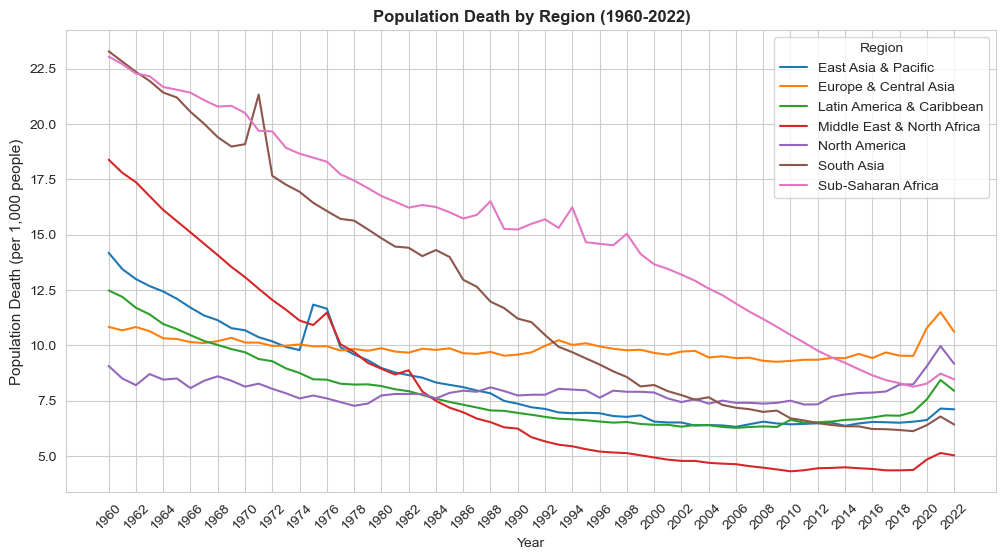

In [119]:
Evolution_by_region1 = df5.groupby(["Region"]).mean(numeric_only=True)
years1 = [str(year) for year in range(1960, 2023)]
Evolution_by_region1 = Evolution_by_region1[years1]
print (Evolution_by_region1)
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
for region1 in Evolution_by_region1.index:
    plt.plot(years1, Evolution_by_region1.loc[region1], label=region1)
plt.xticks([i*2 for i in range(0,32)],fontsize=10,fontweight=550, rotation=45)
plt.xlabel("Year")
plt.ylabel("Population Death (per 1,000 people)",fontsize=11)
plt.title("Population Death by Region (1960-2022)", fontweight=600)
plt.legend(title="Region")
plt.show()

In [121]:
df6 = df_new_birth.merge(df1[['Country Code', 'Region', 'IncomeGroup']], on='Country Code', how='inner')
col6 = ['Country Name', 'Country Code', 'Region', 'IncomeGroup'] + [col for col in df6.columns if col not in ['Country Name', 'Country Code', 'Region', 'IncomeGroup']]
df6 = df6[col6]
print(df6.head(3))

                  Country Name Country Code                     Region  \
0                        Aruba          ABW  Latin America & Caribbean   
1  Africa Eastern and Southern          AFE                        NaN   
2                  Afghanistan          AFG                 South Asia   

   IncomeGroup                        Indicator Name       1960       1961  \
0  High income  Birth rate, crude (per 1,000 people)  33.883000  32.831000   
1          NaN  Birth rate, crude (per 1,000 people)  47.437825  47.527899   
2   Low income  Birth rate, crude (per 1,000 people)  50.340000  50.443000   

        1962       1963      1964  ...       2013       2014       2015  \
0  31.649000  30.416000  29.14700  ...  13.316000  13.533000  12.428000   
1  47.593643  47.631188  47.63984  ...  36.453947  36.034648  35.620577   
2  50.570000  50.703000  50.83100  ...  39.601000  39.105000  38.803000   

        2016       2017     2018       2019       2020       2021       2022  
0  12.3000

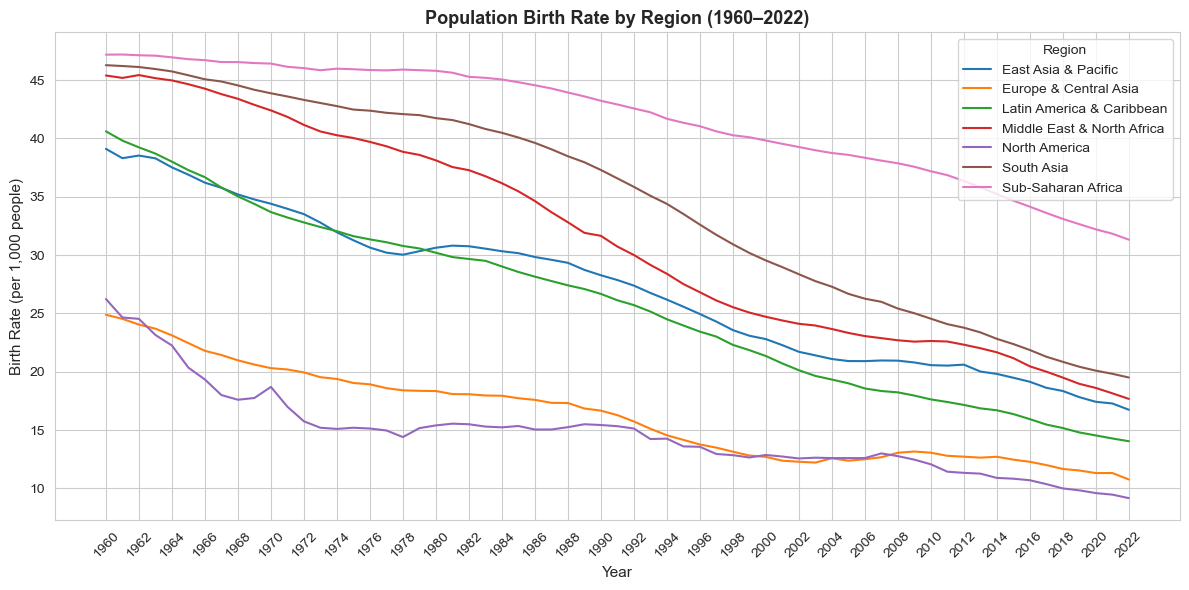

In [125]:
# Group by region and calculate mean birth rates by year
Evolution_by_region_new = df6.groupby("Region").mean(numeric_only=True)

# Select only year columns from 1960 to 2022
years_new = [str(year) for year in range(1960, 2023)]
Evolution_by_region_new = Evolution_by_region_new[years_new]

# Plotting
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

for region_new in Evolution_by_region_new.index:
    plt.plot(years_new, Evolution_by_region_new.loc[region_new], label=region_new)

plt.xticks([i for i in range(0, len(years_new), 2)], labels=years_new[::2], fontsize=10, fontweight=550, rotation=45)
plt.xlabel("Year", fontsize=11)
plt.ylabel("Birth Rate (per 1,000 people)", fontsize=11)
plt.title("Population Birth Rate by Region (1960–2022)", fontsize=13, fontweight=600)
plt.legend(title="Region")
plt.tight_layout()
plt.show()


In [127]:
from sklearn.linear_model import LinearRegression

years = Evolution_by_region.columns
years_numeric = np.array([int(year) for year in years])
predictions = {}

for region in Evolution_by_region.index:
    population_data = Evolution_by_region.loc[region].dropna().values.astype(float)
    valid_years = years_numeric[:len(population_data)].reshape(-1, 1)
    model = LinearRegression()
    model.fit(valid_years, population_data)
    # Future years for prediction
    future_years = np.arange(2024, 2041).reshape(-1, 1)
    future_predictions = model.predict(future_years)
    predictions[region] = future_predictions
future_years_labels = [str(year) for year in range(2024, 2041)]
future_df = pd.DataFrame(predictions, index=future_years_labels).transpose()
print("Predicted Population Growth (2024 - 2040):\n")
print(future_df)

Predicted Population Growth (2024 - 2040):

                                2024      2025      2026      2027      2028  \
East Asia & Pacific         0.578763  0.544189  0.509616  0.475042  0.440469   
Europe & Central Asia       0.000653 -0.021685 -0.044023 -0.066361 -0.088698   
Latin America & Caribbean   0.618505  0.588082  0.557659  0.527236  0.496813   
Middle East & North Africa  2.011969  1.974121  1.936273  1.898425  1.860577   
North America               0.494291  0.479144  0.463996  0.448849  0.433702   
South Asia                  1.402756  1.381420  1.360084  1.338748  1.317412   
Sub-Saharan Africa          2.439384  2.436902  2.434419  2.431937  2.429455   

                                2029      2030      2031      2032      2033  \
East Asia & Pacific         0.405895  0.371322  0.336749  0.302175  0.267602   
Europe & Central Asia      -0.111036 -0.133374 -0.155712 -0.178050 -0.200388   
Latin America & Caribbean   0.466390  0.435967  0.405543  0.375120  0.34469

In [129]:
years_numeric1 = np.array([int(year1) for year1 in years1]).reshape(-1, 1)
predictions = {}
for region in Evolution_by_region1.index:
    population_data1 = Evolution_by_region1.loc[region].values
    model1 = LinearRegression()
    model1.fit(years_numeric1, population_data1)
    future_years1 = np.array([year1 for year1 in range(2023, 2041)]).reshape(-1, 1)
    future_predictions1 = model1.predict(future_years1)
    predictions[region] = future_predictions1
future_years_list1 = [str(year1) for year1 in range(2023, 2041)]
future_df1 = pd.DataFrame(predictions, index=future_years_list1)
future_df1 = future_df1.transpose()
print(f"Predicted Population Death (2023 - 2040):\n")
print(future_df1)

Predicted Population Death (2023 - 2040):

                                2023      2024      2025      2026      2027  \
East Asia & Pacific         4.890218  4.780671  4.671124  4.561577  4.452029   
Europe & Central Asia       9.556802  9.546644  9.536487  9.526330  9.516172   
Latin America & Caribbean   5.503164  5.430108  5.357051  5.283995  5.210939   
Middle East & North Africa  1.333900  1.124176  0.914451  0.704726  0.495002   
North America               7.815023  7.811203  7.807384  7.803565  7.799746   
South Asia                  2.974176  2.683770  2.393364  2.102959  1.812553   
Sub-Saharan Africa          7.657190  7.422024  7.186857  6.951691  6.716524   

                                2028      2029      2030      2031      2032  \
East Asia & Pacific         4.342482  4.232935  4.123388  4.013841  3.904293   
Europe & Central Asia       9.506015  9.495857  9.485700  9.475542  9.465385   
Latin America & Caribbean   5.137882  5.064826  4.991770  4.918714  4.845657

In [131]:
years_numeric_new = np.array([int(year_new) for year_new in years_new]).reshape(-1, 1)
predictions = {}
for region in Evolution_by_region_new.index:
    population_data_new = Evolution_by_region_new.loc[region].values
    model_new = LinearRegression()
    model_new.fit(years_numeric_new, population_data_new)
    future_years_new = np.array([year_new for year_new in range(2023, 2041)]).reshape(-1, 1)
    future_predictions_new = model_new.predict(future_years_new)
    predictions[region] = future_predictions_new
future_years_list_new = [str(year_new) for year_new in range(2023, 2041)]
future_df_new = pd.DataFrame(predictions, index=future_years_list_new)
future_df_new = future_df_new.transpose()
print(f"Predicted Population Birth (2023 - 2040):\n")
print(future_df_new)

Predicted Population Birth (2023 - 2040):

                                 2023       2024       2025       2026  \
East Asia & Pacific         15.873940  15.522518  15.171095  14.819673   
Europe & Central Asia        9.602895   9.393854   9.184813   8.975773   
Latin America & Caribbean   12.393319  11.974740  11.556160  11.137580   
Middle East & North Africa  15.804130  15.313724  14.823318  14.332911   
North America                8.877274   8.694636   8.511998   8.329360   
South Asia                  19.202601  18.722681  18.242761  17.762841   
Sub-Saharan Africa          33.532269  33.278473  33.024677  32.770880   

                                 2027       2028       2029       2030  \
East Asia & Pacific         14.468251  14.116828  13.765406  13.413984   
Europe & Central Asia        8.766732   8.557691   8.348650   8.139610   
Latin America & Caribbean   10.719000  10.300420   9.881840   9.463260   
Middle East & North Africa  13.842505  13.352099  12.861692  12.3712

In [133]:
years_numeric2 = np.array([int(year2) for year2 in years]).reshape(-1, 1)
predictions = {}
for region in total_population1.index:
    population_data2 = total_population1.loc[region].values
    min_length = min(len(years_numeric2), len(population_data2))
    years_numeric2_adjusted = years_numeric2[:min_length]
    population_data2_adjusted = population_data2[:min_length]
    model2 = LinearRegression()
    model2.fit(years_numeric2_adjusted, population_data2_adjusted)
    future_years2 = np.array([year2 for year2 in range(2024, 2041)]).reshape(-1, 1)
    future_predictions2 = model2.predict(future_years2)
    predictions[region] = future_predictions2
future_years_list2 = [str(year2) for year2 in range(2024, 2041)]
future_df2 = pd.DataFrame(predictions, index=future_years_list2)
future_df2 = future_df2.transpose()
print(f"Total Predicted Population from 2024 to 2040:\n")
print(future_df2)

Total Predicted Population from 2024 to 2040:

                                    2024          2025          2026  \
East Asia & Pacific         6.774248e+07  6.834592e+07  6.894936e+07   
Europe & Central Asia       1.640058e+07  1.646618e+07  1.653177e+07   
Latin America & Caribbean   1.635259e+07  1.652772e+07  1.670284e+07   
Middle East & North Africa  2.330994e+07  2.361934e+07  2.392875e+07   
North America               1.268672e+08  1.278274e+08  1.287876e+08   
South Asia                  2.474127e+08  2.503644e+08  2.533161e+08   
Sub-Saharan Africa          2.354838e+07  2.388382e+07  2.421927e+07   

                                    2027          2028          2029  \
East Asia & Pacific         6.955280e+07  7.015624e+07  7.075968e+07   
Europe & Central Asia       1.659737e+07  1.666296e+07  1.672856e+07   
Latin America & Caribbean   1.687797e+07  1.705310e+07  1.722823e+07   
Middle East & North Africa  2.423816e+07  2.454757e+07  2.485698e+07   
North America   

In [135]:
Evolution_by_region_transposed = Evolution_by_region.copy()
future_df_transposed = future_df.copy()
merged_df = pd.concat([Evolution_by_region_transposed, future_df_transposed], axis=1)
years_format = type(Evolution_by_region.columns[0])
all_years = [years_format(year) for year in range(1961, 2041)]
complete_df = pd.DataFrame(index=Evolution_by_region.index, columns=all_years)
for year in Evolution_by_region.columns:
    complete_df[year] = Evolution_by_region[year]
for year in future_df.columns:
    if year in complete_df.columns:
        complete_df[year] = future_df[year]
print(f"Predicted Population Growth (1961 - 2040):")
print(complete_df)

Predicted Population Growth (1961 - 2040):
                                1961      1962      1963      1964      1965  \
Region                                                                         
East Asia & Pacific         2.434776  2.664984  2.679007  3.147065  2.965752   
Europe & Central Asia       1.600985  1.620991  1.634078  1.598202  1.503330   
Latin America & Caribbean   2.427935  2.343857  2.601084  2.303626  2.348673   
Middle East & North Africa  3.621987  3.837276  3.836941  3.859449  3.790406   
North America               1.933862  1.984304  1.920100  1.869097  1.766558   
South Asia                  2.431185  2.474084  2.504317  2.521459  2.649120   
Sub-Saharan Africa          2.252864  2.340917  2.350364  2.359075  2.352999   

                                1966      1967      1968      1969      1970  \
Region                                                                         
East Asia & Pacific         2.375565  2.218635  2.124835  2.126190  2.270302

In [137]:
Evolution_by_region_transposed1 = Evolution_by_region1.copy()
future_df_transposed1 = future_df1.copy()
merged_df1 = pd.concat([Evolution_by_region_transposed1, future_df_transposed1], axis=1)
years_format1 = type(Evolution_by_region1.columns[0]) 
all_years1 = [years_format1(year1) for year1 in range(1960, 2041)]
complete_df1 = pd.DataFrame(index=Evolution_by_region1.index, columns=all_years1)

for year1 in Evolution_by_region1.columns:
    complete_df1[year1] = Evolution_by_region1[year1]

for year1 in future_df1.columns:
    if year1 in complete_df1.columns:
        complete_df1[year1] = future_df1[year1]
print(f"Predicted Population Death (1960 - 2040):")
print(complete_df1)

Predicted Population Death (1960 - 2040):
                                 1960       1961       1962       1963  \
Region                                                                   
East Asia & Pacific         14.177647  13.441471  12.990412  12.673971   
Europe & Central Asia       10.830624  10.676309  10.824562  10.635537   
Latin America & Caribbean   12.476220  12.187537  11.693512  11.396366   
Middle East & North Africa  18.383750  17.792400  17.365450  16.738050   
North America                9.066667   8.500000   8.200000   8.700000   
South Asia                  23.277750  22.813500  22.347375  21.942750   
Sub-Saharan Africa          23.039638  22.700511  22.272872  22.153532   

                                 1964       1965       1966       1967  \
Region                                                                   
East Asia & Pacific         12.431382  12.100765  11.701353  11.345471   
Europe & Central Asia       10.317142  10.282697  10.144137  10.09989

In [139]:
Evolution_by_region_transposed_new = Evolution_by_region_new.copy()
future_df_transposed_new = future_df_new.copy()
merged_df_new = pd.concat([Evolution_by_region_transposed_new, future_df_transposed_new], axis=1)
years_format_new = type(Evolution_by_region_new.columns[0]) 
all_years_new = [years_format_new(year_new) for year_new in range(1960, 2041)]
complete_df_new = pd.DataFrame(index=Evolution_by_region_new.index, columns=all_years_new)

for year_new in Evolution_by_region_new.columns:
    complete_df_new[year_new] = Evolution_by_region_new[year_new]

for year_new in future_df_new.columns:
    if year_new in complete_df_new.columns:
        complete_df_new[year_new] = future_df_new[year_new]
print(f"Predicted Population Birth (1960 - 2040):")
print(complete_df_new)

Predicted Population Birth (1960 - 2040):
                                 1960       1961       1962       1963  \
Region                                                                   
East Asia & Pacific         39.104176  38.303441  38.530706  38.290735   
Europe & Central Asia       24.881246  24.534042  24.043481  23.691328   
Latin America & Caribbean   40.606756  39.811268  39.231537  38.697976   
Middle East & North Africa  45.392800  45.183950  45.428000  45.162150   
North America               26.233333  24.650000  24.533333  23.150000   
South Asia                  46.276375  46.204000  46.117500  45.944875   
Sub-Saharan Africa          47.178553  47.190213  47.126553  47.090638   

                                 1964       1965       1966       1967  \
Region                                                                   
East Asia & Pacific         37.516941  36.887824  36.204176  35.766471   
Europe & Central Asia       23.116874  22.455520  21.791202  21.43435

In [141]:
Evolution_by_region_transposed2 = total_population1.copy()
future_df_transposed2 = future_df2.copy()
merged_df2 = pd.concat([Evolution_by_region_transposed2, future_df_transposed2], axis=1)
years_format2 = type(total_population1.columns[0]) 
all_years2 = [years_format2(year2) for year2 in range(1961, 2041)]
complete_df2 = pd.DataFrame(index=total_population1.index, columns=all_years2)

for year2 in total_population1.columns:
    complete_df2[year2] = total_population1[year2]

for year2 in future_df2.columns:
    if year2 in complete_df2.columns:
        complete_df2[year2] = future_df2[year2]
print(f"Total Predicted Population from 1960 to 2040:")
print(complete_df2)

Total Predicted Population from 1960 to 2040:
                                    1961          1962          1963  \
Region                                                                 
East Asia & Pacific         2.793723e+07  2.831795e+07  2.900685e+07   
Europe & Central Asia       1.164741e+07  1.178176e+07  1.191706e+07   
Latin America & Caribbean   5.350889e+06  5.500911e+06  5.654754e+06   
Middle East & North Africa  5.296665e+06  5.441520e+06  5.591451e+06   
North America               6.733504e+07  6.839875e+07  6.941711e+07   
South Asia                  7.206903e+07  7.384038e+07  7.564543e+07   
Sub-Saharan Africa          4.859200e+06  4.979717e+06  5.104890e+06   

                                    1964          1965          1966  \
Region                                                                 
East Asia & Pacific         2.968675e+07  3.038431e+07  3.116637e+07   
Europe & Central Asia       1.205273e+07  1.218420e+07  1.230075e+07   
Latin America & C

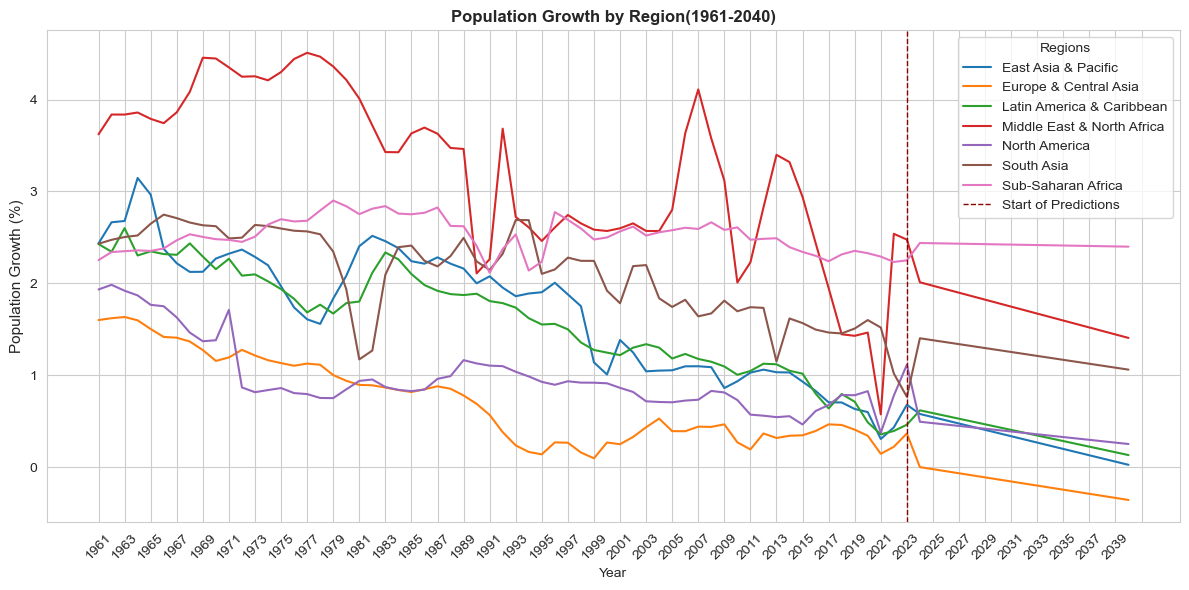

In [143]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
for region in complete_df.index:
    plt.plot(complete_df.columns, complete_df.loc[region], label=region)
plt.axvline(x='2023', color='darkred', linestyle='--', linewidth=1, label='Start of Predictions')
plt.xticks([i*2 for i in range(0,41)],fontsize=10,fontweight=550, rotation=45)
plt.title("Population Growth by Region(1961-2040)", fontweight=600)
plt.xlabel("Year")
plt.ylabel("Population Growth (%)",fontsize=11)
plt.legend(title="Regions")
plt.tight_layout()
plt.show()

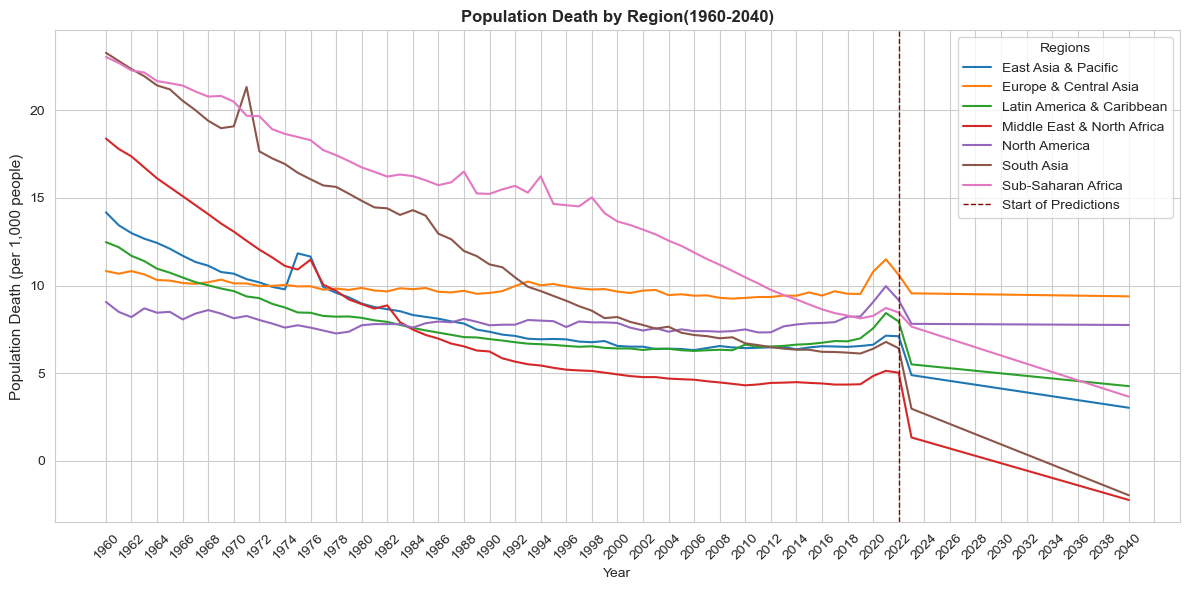

In [145]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
for region1 in complete_df1.index:
    plt.plot(complete_df1.columns, complete_df1.loc[region1], label=region1)
plt.axvline(x='2022', color='darkred', linestyle='--', linewidth=1, label='Start of Predictions')
plt.xticks([i*2 for i in range(0,42)],fontsize=10,fontweight=550, rotation=45)
plt.title("Population Death by Region(1960-2040)", fontweight=600)
plt.xlabel("Year")
plt.ylabel("Population Death (per 1,000 people)",fontsize=11)
plt.legend(title="Regions")
plt.tight_layout()
plt.show()

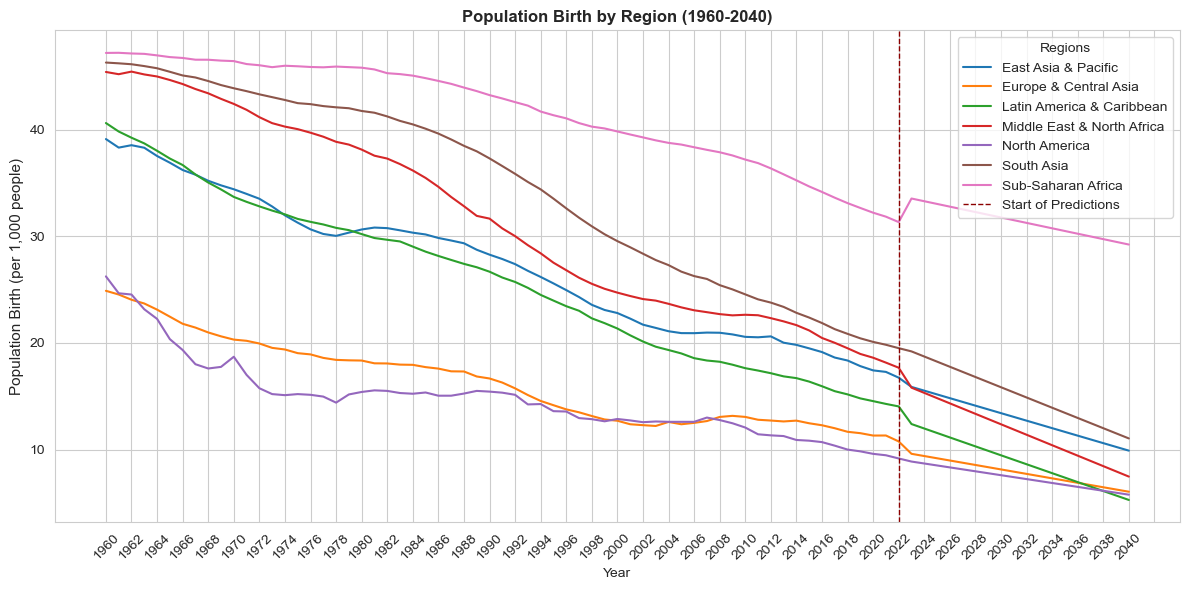

In [147]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
for region_new in complete_df_new.index:
    plt.plot(complete_df_new.columns, complete_df_new.loc[region_new], label=region_new)
plt.axvline(x='2022', color='darkred', linestyle='--', linewidth=1, label='Start of Predictions')
plt.xticks([i*2 for i in range(0,42)],fontsize=10,fontweight=550, rotation=45)
plt.title("Population Birth by Region (1960-2040)", fontweight=600)
plt.xlabel("Year")
plt.ylabel("Population Birth (per 1,000 people)",fontsize=11)
plt.legend(title="Regions")
plt.tight_layout()
plt.show()

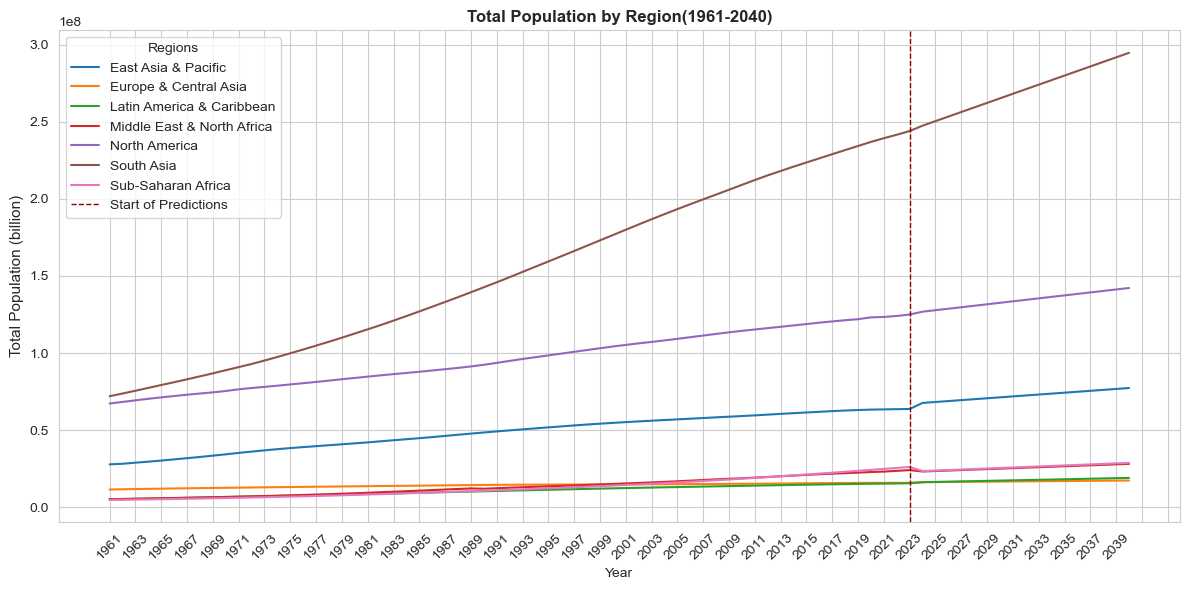

In [149]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
for region2 in complete_df2.index:
    plt.plot(complete_df2.columns, complete_df2.loc[region2], label=region2)
plt.axvline(x='2023', color='darkred', linestyle='--', linewidth=1, label='Start of Predictions')
plt.xticks([i*2 for i in range(0,42)],fontsize=10,fontweight=550, rotation=45)
plt.title("Total Population by Region(1961-2040)", fontweight=600)
plt.xlabel("Year")
plt.ylabel("Total Population (billion)",fontsize=11)
plt.legend(title="Regions")
plt.tight_layout()
plt.show()

In [151]:
X = world_population_percentage_df["Year"].values.reshape(-1, 1)
y = world_population_percentage_df["World Population (%)"].values.reshape(-1, 1)
model = LinearRegression()
model.fit(X, y)
# Predict for years
future_years = np.arange(2024, 2041).reshape(-1, 1)
future_predictions = model.predict(future_years)
future_predictions_df = pd.DataFrame({
    "Year": future_years.flatten(),
    "World Population (%)": future_predictions.flatten()
})
print("Predicted World Population Growth Between 2024 and 2040:")
print(future_predictions_df)

Predicted World Population Growth Between 2024 and 2040:
    Year  World Population (%)
0   2024              0.980461
1   2025              0.962019
2   2026              0.943578
3   2027              0.925137
4   2028              0.906695
5   2029              0.888254
6   2030              0.869813
7   2031              0.851371
8   2032              0.832930
9   2033              0.814488
10  2034              0.796047
11  2035              0.777606
12  2036              0.759164
13  2037              0.740723
14  2038              0.722282
15  2039              0.703840
16  2040              0.685399


In [153]:
print("Predicted the world population from 1961 to 2040")
full_population_growth_df = pd.concat([world_population_percentage_df, future_predictions_df], ignore_index=True)
print (full_population_growth_df)

Predicted the world population from 1961 to 2040
    Year  World Population (%)
0   1961              1.364880
1   1962              1.782818
2   1963              2.139300
3   1964              2.110202
4   1965              2.083637
..   ...                   ...
75  2036              0.759164
76  2037              0.740723
77  2038              0.722282
78  2039              0.703840
79  2040              0.685399

[80 rows x 2 columns]


In [155]:
X1 = total_population_df["Year"].values.reshape(-1, 1)
y1 = total_population_df["Total Population"].values.reshape(-1, 1)
model1 = LinearRegression()
model1.fit(X1, y1)
future_years1 = np.arange(2024, 2041).reshape(-1, 1)
future_predictions1 = model1.predict(future_years1)
future_predictions_df1 = pd.DataFrame({
    "Year": future_years1.flatten(),
    "Total Population": future_predictions1.flatten()
})
print("Predicted Total World Population Between 2024 and 2040:")
print(future_predictions_df1)

Predicted Total World Population Between 2024 and 2040:
    Year  Total Population
0   2024      8.146304e+09
1   2025      8.228999e+09
2   2026      8.311695e+09
3   2027      8.394390e+09
4   2028      8.477086e+09
5   2029      8.559781e+09
6   2030      8.642477e+09
7   2031      8.725172e+09
8   2032      8.807867e+09
9   2033      8.890563e+09
10  2034      8.973258e+09
11  2035      9.055954e+09
12  2036      9.138649e+09
13  2037      9.221345e+09
14  2038      9.304040e+09
15  2039      9.386736e+09
16  2040      9.469431e+09


In [157]:
print("Predicted Total population from 1961 to 2040")
full_population_growth_df1 = pd.concat([total_population_df, future_predictions_df1], ignore_index=True)
print (full_population_growth_df1)

Predicted Total population from 1961 to 2040
    Year  Total Population
0   1960      3.021529e+09
1   1961      3.062769e+09
2   1962      3.117373e+09
3   1963      3.184063e+09
4   1964      3.251253e+09
..   ...               ...
76  2036      9.138649e+09
77  2037      9.221345e+09
78  2038      9.304040e+09
79  2039      9.386736e+09
80  2040      9.469431e+09

[81 rows x 2 columns]


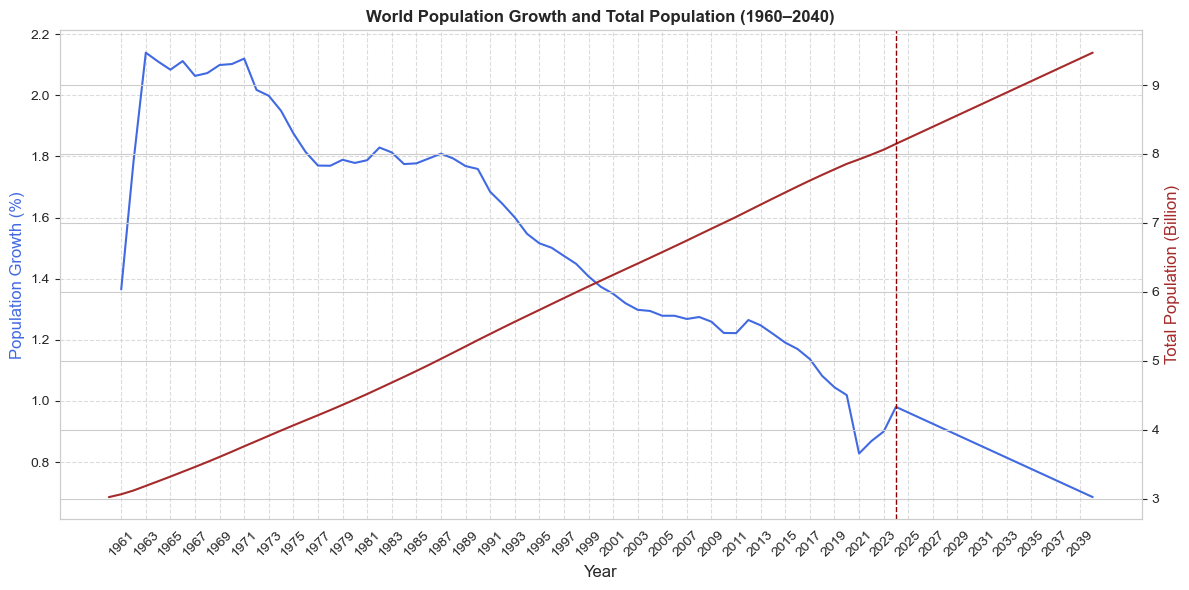

In [159]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax_left = plt.gca()
ax_left.plot(full_population_growth_df["Year"], full_population_growth_df["World Population (%)"],
             label="Population Growth (%)", color="royalblue")
ax_left.set_xlabel("Year", fontsize=12)
ax_left.set_ylabel("Population Growth (%)", fontsize=12, color="royalblue")
ax_left.grid(True, linestyle="--", alpha=0.7)
ax_left.set_xticks(full_population_growth_df["Year"][::2])
ax_left.set_xticklabels(full_population_growth_df["Year"][::2], rotation=45)
ax_right = ax_left.twinx()
ax_right.plot(full_population_growth_df1["Year"], full_population_growth_df1["Total Population"] / 1e9,
              label="Total Population (Billion)", color="brown")
ax_right.set_ylabel("Total Population (Billion)", fontsize=12, color="brown")
plt.axvline(x=2024, color='darkred', linestyle='--', linewidth=1)
plt.title("World Population Growth and Total Population (1960–2040)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [161]:
years1 = [int(col1) for col1 in death_population_by_year.columns if col1.isdigit()]
actual_death_rates = death_population_by_year.loc[:, map(str, years1)].values.flatten()
death_population_by_year_df = pd.DataFrame({
    "Year": years1,
    "Death Rate": actual_death_rates
})
X2 = death_population_by_year_df["Year"].values.reshape(-1, 1)
y2 = death_population_by_year_df["Death Rate"].values.reshape(-1, 1)
model2 = LinearRegression()
model2.fit(X2, y2)
future_years2 = np.arange(2023, 2041).reshape(-1, 1)
future_predictions2 = model2.predict(future_years2).flatten()
future_predictions_df2 = pd.DataFrame({
    "Year": future_years2.flatten(),
    "Predicted Death Rate": future_predictions2
})
print("Predicted Death Rate (per 1,000 people) from 2023 to 2040:")
print(future_predictions_df2)

Predicted Death Rate (per 1,000 people) from 2023 to 2040:
    Year  Predicted Death Rate
0   2023              6.459308
1   2024              6.352838
2   2025              6.246367
3   2026              6.139896
4   2027              6.033425
5   2028              5.926955
6   2029              5.820484
7   2030              5.714013
8   2031              5.607543
9   2032              5.501072
10  2033              5.394601
11  2034              5.288131
12  2035              5.181660
13  2036              5.075189
14  2037              4.968718
15  2038              4.862248
16  2039              4.755777
17  2040              4.649306


In [163]:
years_new = [int(col_new) for col_new in birth_population_by_year.columns if col_new.isdigit()]
actual_birth_rates = birth_population_by_year.loc[:, map(str, years_new)].values.flatten()
birth_population_by_year_df = pd.DataFrame({
    "Year": years_new,
    "Birth Rate": actual_birth_rates
})
X3 = birth_population_by_year_df["Year"].values.reshape(-1, 1)
y3 = birth_population_by_year_df["Birth Rate"].values.reshape(-1, 1)
model3 = LinearRegression()
model3.fit(X3, y3)
future_years3 = np.arange(2023, 2041).reshape(-1, 1)
future_predictions3 = model3.predict(future_years3).flatten()
future_predictions_df3 = pd.DataFrame({
    "Year": future_years3.flatten(),
    "Predicted Birth Rate": future_predictions3
})
print("Predicted Birth Rate (per 1,000 people) from 2024 to 2040:")
print(future_predictions_df3)

Predicted Birth Rate (per 1,000 people) from 2024 to 2040:
    Year  Predicted Birth Rate
0   2023             16.203828
1   2024             15.916381
2   2025             15.628934
3   2026             15.341487
4   2027             15.054040
5   2028             14.766593
6   2029             14.479146
7   2030             14.191699
8   2031             13.904252
9   2032             13.616805
10  2033             13.329359
11  2034             13.041912
12  2035             12.754465
13  2036             12.467018
14  2037             12.179571
15  2038             11.892124
16  2039             11.604677
17  2040             11.317230


In [165]:
actual_df = death_population_by_year_df.copy()
actual_df["Predicted Death Rate"] = np.nan
future_predictions_df2["Death Rate"] = np.nan
future_predictions_df2 = future_predictions_df2[["Year", "Death Rate", "Predicted Death Rate"]]
combined_df = pd.concat([actual_df, future_predictions_df2], ignore_index=True)
combined_df["Death Rate (per 1000)"] = (
    combined_df["Death Rate"].combine_first(combined_df["Predicted Death Rate"])
)
final_df = combined_df[["Year", "Death Rate (per 1000)"]]
print("Predicted Death Rate (per 1,000 people) from 1960 to 2040:")
print(final_df)

Predicted Death Rate (per 1,000 people) from 1960 to 2040:
    Year  Death Rate (per 1000)
0   1960              17.227560
1   1961              14.569443
2   1962              13.600995
3   1963              13.444486
4   1964              13.515490
..   ...                    ...
76  2036               5.075189
77  2037               4.968718
78  2038               4.862248
79  2039               4.755777
80  2040               4.649306

[81 rows x 2 columns]


In [167]:
actual_df_new = birth_population_by_year_df.copy()
actual_df_new["Predicted Birth Rate"] = np.nan
future_predictions_df3["Birth Rate"] = np.nan
future_predictions_df3 = future_predictions_df3[["Year", "Birth Rate", "Predicted Birth Rate"]]
combined_df_new = pd.concat([actual_df_new, future_predictions_df3], ignore_index=True)
combined_df_new["Birth Rate (per 1000)"] = (
    combined_df_new["Birth Rate"].combine_first(combined_df_new["Predicted Birth Rate"])
)
final_df_new = combined_df_new[["Year", "Birth Rate (per 1000)"]]
print("Predicted Birth Rate (per 1,000 people) from 1960 to 2040:")
print(final_df_new)

Predicted Birth Rate (per 1,000 people) from 1960 to 2040:
    Year  Birth Rate (per 1000)
0   1960              31.864856
1   1961              31.122660
2   1962              35.074813
3   1963              36.251294
4   1964              35.106656
..   ...                    ...
76  2036              12.467018
77  2037              12.179571
78  2038              11.892124
79  2039              11.604677
80  2040              11.317230

[81 rows x 2 columns]


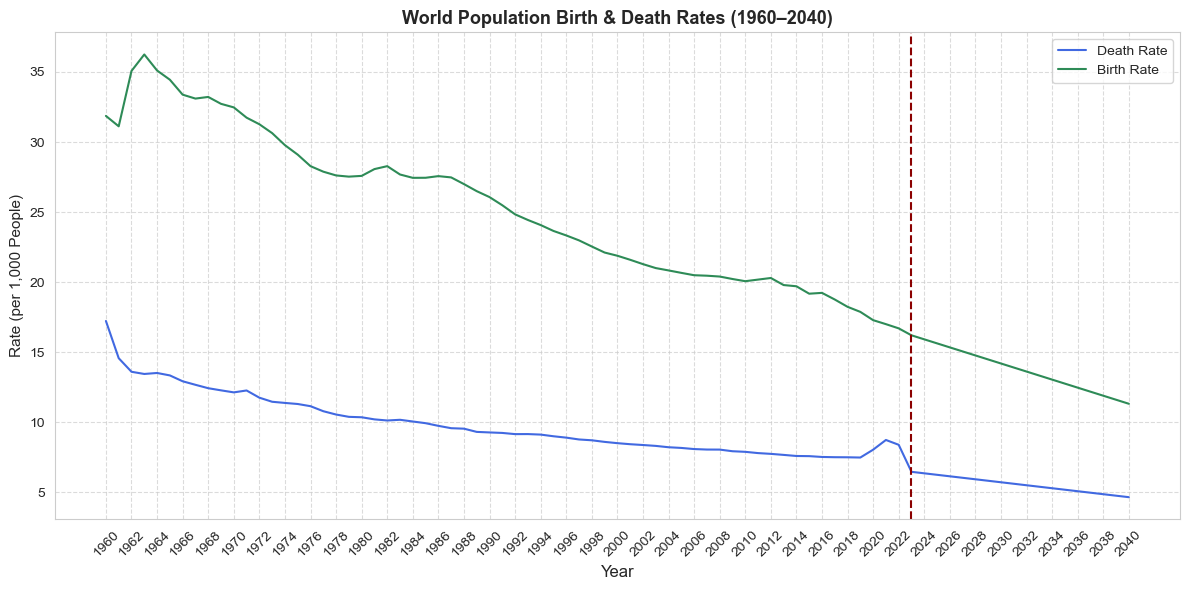

In [169]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
# Plot Death Rate
plt.plot(
    final_df["Year"],
    final_df["Death Rate (per 1000)"],
    label="Death Rate",
    color="royalblue"
)
# Plot Birth Rate
plt.plot(
    final_df_new["Year"],
    final_df_new["Birth Rate (per 1000)"],
    label="Birth Rate",
    color="seagreen"
)
plt.axvline(x=2023, color='darkred', linestyle='--')
# Labels, title, legend, and grid
plt.title("World Population Birth & Death Rates (1960–2040)", fontsize=13, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Rate (per 1,000 People)", fontsize=11)
plt.xticks(ticks=final_df["Year"][::2], rotation=45)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [187]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

X = world_population_percentage_df.index.astype(int).values.reshape(-1, 1)
y = world_population_percentage_df.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_binned, test_size=0.2, random_state=42, stratify=y_binned)
# Keep original continuous y for regression
X_train, X_test, y_train_orig, y_test_orig = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y_binned)
# Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train_orig)
y_pred_reg = lin_reg.predict(X_test)
print("Linear Regression (LR):")
print(f"  Mean Squared Error: {mean_squared_error(y_test_orig, y_pred_reg) * 100:.2f}%")
print(f"  Mean Absolute Error: {mean_absolute_error(y_test_orig, y_pred_reg) * 100:.2f}%" )
print(f"  R-squared : {r2_score(y_test_orig, y_pred_reg) * 100:.2f}%")

Linear Regression (LR):
  Mean Squared Error: 0.60%
  Mean Absolute Error: 3.11%
  R-squared : 94.53%


In [189]:

rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Recurrent Neural Network (RNN):")
print(f"  Mean Squared Error: {mean_squared_error(y_test, y_pred_rf) * 100:.2f}%")
print(f"  Mean Absolute Error: {mean_absolute_error(y_test, y_pred_rf) * 100:.2f}%" )
print(f"  R-squared : {r2_score(y_test, y_pred_rf) * 100:.2f}%")

Recurrent Neural Network (RNN):
  Mean Squared Error: 7.84%
  Mean Absolute Error: 14.15%
  R-squared : 88.58%


In [191]:

cnn_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
cnn_model.fit(X_train, y_train)
y_pred_cnn = cnn_model.predict(X_test)
print("Convolutional Neural Network (CNN):")
print(f"  Mean Squared Error: {mean_squared_error(y_test, y_pred_cnn) * 100:.2f}%")
print(f"  Mean Absolute Error: {mean_absolute_error(y_test, y_pred_cnn) * 100:.2f}%" )
print(f"  R-squared : {r2_score(y_test, y_pred_cnn) * 100:.2f}%")

Convolutional Neural Network (CNN):
  Mean Squared Error: 8.66%
  Mean Absolute Error: 18.47%
  R-squared : 87.39%


19:25:27 - cmdstanpy - INFO - Chain [1] start processing
19:25:28 - cmdstanpy - INFO - Chain [1] done processing


Prophet Model Evaluation on Known Data:
  Mean Squared Error: 1.41%
  Mean Absolute Error: 7.52%
  R-Squared: 89.14%


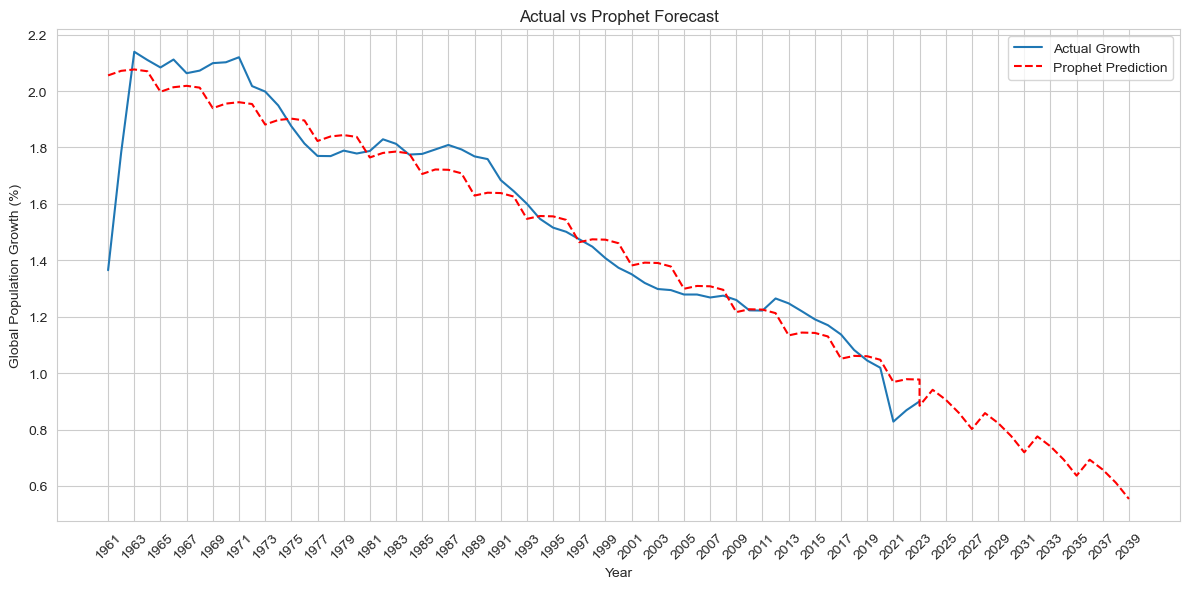

In [215]:
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Prepare data for Prophet
df_prophet = world_population_percentage_df.rename(columns={
    'Year': 'ds',
    'World Population (%)': 'y'
})
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'], format='%Y')

# Initialize and train Prophet model
model = Prophet()
model.fit(df_prophet)

# Forecast up to 2040
last_year = df_prophet['ds'].dt.year.max()
years_to_forecast = 2040 - last_year
future = model.make_future_dataframe(periods=years_to_forecast, freq='YE')
forecast = model.predict(future)

# Evaluation on known data
y_true = df_prophet['y']
y_pred = forecast['yhat'][:len(df_prophet)]

print("Prophet Model Evaluation on Known Data:")
print(f"  Mean Squared Error: {mean_squared_error(y_true, y_pred) * 100:.2f}%")
print(f"  Mean Absolute Error: {mean_absolute_error(y_true, y_pred) * 100:.2f}%")
print(f"  R-Squared: {r2_score(y_true, y_pred) * 100:.2f}%")
plt.figure(figsize=(12, 6))
plt.plot(df_prophet['ds'].dt.year, df_prophet['y'], label='Actual Growth')
plt.plot(forecast['ds'].dt.year, forecast['yhat'], 'r--', label='Prophet Prediction')
plt.xlabel("Year")
plt.ylabel("Global Population Growth (%)")
plt.title("Actual vs Prophet Forecast")
plt.xticks(ticks=range(df_prophet['ds'].dt.year.min(), 2041, 2), rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()